# Similarity Score Models
Three methods compared: User-User CF, Item-Item CF, Gradient Boosting hybrid.
Evaluation: Hit Rate@10, Recall@10, NDCG@10.

In [2]:
import ast
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import GradientBoostingClassifier

## 1. Load Data

In [3]:
import os
os.chdir('/Users/saurav/Documents/Spring-2026/CS_4641_Machine_Learning/movie-recommendation-system/data')

movies  = pd.read_csv('./movies_metadata.csv', low_memory=False)
keywords = pd.read_csv('./keywords.csv')
credits = pd.read_csv('./credits.csv')
ratings  = pd.read_csv('./ratings_small.csv')

# --- same cleaning as exploration notebook ---
movies['id']       = pd.to_numeric(movies['id'], errors='coerce')
ratings['movieId'] = pd.to_numeric(ratings['movieId'], errors='coerce')
movies  = movies.dropna(subset=['id']).copy()
ratings = ratings.dropna(subset=['movieId']).copy()
movies['id']       = movies['id'].astype('int64')
ratings['movieId'] = ratings['movieId'].astype('int64')

movies  = movies.drop_duplicates(subset='id')
ratings = ratings.dropna(subset=['rating'])

active_users = ratings['userId'].value_counts()
active_users = active_users[active_users >= 3].index
ratings = ratings[ratings['userId'].isin(active_users)]

# keep only movies that appear in ratings
rated_ids = set(ratings['movieId'].unique())
movies = movies[movies['id'].isin(rated_ids)]

print('Movies:', movies.shape, '  Ratings:', ratings.shape)

Movies: (2830, 24)   Ratings: (100004, 4)


## 2. Shared Structures

In [4]:
# User-item matrix (rows=users, cols=movies, values=ratings, NaN where unrated)
user_item = ratings.pivot_table(index='userId', columns='movieId', values='rating')
user_item_filled = user_item.fillna(0)   # zero-filled copy for dot products

all_movie_ids = set(user_item.columns)
all_user_ids  = list(user_item.index)

# Precompute user-user cosine similarity matrix (users x users)
user_sim_matrix = cosine_similarity(user_item_filled.values)   # shape (U, U)

print(f'User-item matrix: {user_item.shape}')
print(f'User similarity matrix: {user_sim_matrix.shape}')

User-item matrix: (671, 9066)
User similarity matrix: (671, 671)


## 3. Item-Item Feature Matrix

In [5]:
def parse_name_list(s):
    """Parse a stringified list-of-dicts and return space-joined names."""
    try:
        return ' '.join(d['name'] for d in ast.literal_eval(s))
    except Exception:
        return ''

def parse_credits(crew_str, cast_str):
    """Extract director from crew and top 3 billed actors from cast."""
    try:
        director = ' '.join(
            d['name'] for d in ast.literal_eval(crew_str)
            if d.get('job') == 'Director'
        )
    except Exception:
        director = ''
    try:
        top_cast = ' '.join(
            d['name'] for d in ast.literal_eval(cast_str)[:3]
        )
    except Exception:
        top_cast = ''
    return director + ' ' + top_cast

kw_lookup      = dict(zip(keywords['id'], keywords['keywords']))
credits['id']  = pd.to_numeric(credits['id'], errors='coerce').astype('Int64')
crew_lookup    = dict(zip(credits['id'], credits['crew']))
cast_lookup    = dict(zip(credits['id'], credits['cast']))

movies['genres_str']   = movies['genres'].apply(parse_name_list)
movies['keywords_str'] = movies['id'].apply(lambda mid: parse_name_list(kw_lookup.get(mid, '[]')))
movies['credits_str']  = movies['id'].apply(lambda mid: parse_credits(
    crew_lookup.get(mid, '[]'),
    cast_lookup.get(mid, '[]')
))

# CountVectorizer version (original)
movies['item_features'] = movies['genres_str'] + ' ' + movies['keywords_str']

# TF-IDF version (genres + keywords + credits)
movies['item_features_tfidf'] = movies['genres_str'] + ' ' + movies['keywords_str'] + ' ' + movies['credits_str']

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer       = CountVectorizer(stop_words='english')
item_feat_matrix = vectorizer.fit_transform(movies['item_features'])
item_sim_matrix  = cosine_similarity(item_feat_matrix)

vectorizer_tfidf       = TfidfVectorizer(stop_words='english')
item_feat_matrix_tfidf = vectorizer_tfidf.fit_transform(movies['item_features_tfidf'])
item_sim_matrix_tfidf  = cosine_similarity(item_feat_matrix_tfidf)

movie_id_to_idx = {mid: i for i, mid in enumerate(movies['id'])}

print(f'Item similarity matrix (Count):  {item_sim_matrix.shape}')
print(f'Item similarity matrix (TF-IDF): {item_sim_matrix_tfidf.shape}')

Item similarity matrix (Count):  (2830, 2830)
Item similarity matrix (TF-IDF): (2830, 2830)


## 4. Scoring Functions
Each function takes a `user_id` and a list of `candidate_movie_ids`
and returns a **numpy array of scores** in the same order.

In [6]:
TOP_N_USERS = 10   # neighbours for user-user CF
K = 10             # evaluation cutoff

user_idx_map = {uid: i for i, uid in enumerate(user_item_filled.index)}


def score_user_user(user_id, candidate_ids):
    """Average rating of the top-N similar users for each candidate movie."""
    u_idx = user_idx_map[user_id]
    sims  = user_sim_matrix[u_idx]                         # (U,)
    top_n_idx = np.argsort(sims)[::-1][1:TOP_N_USERS + 1] # exclude self
    neighbour_ratings = user_item_filled.values[top_n_idx][:, [user_item_filled.columns.get_loc(m) for m in candidate_ids]]
    return neighbour_ratings.mean(axis=0)


def score_item_item(user_id, candidate_ids):
    """For each candidate, average item-item similarity to the user's rated movies."""
    rated = ratings[ratings['userId'] == user_id]['movieId'].values
    rated_idxs = [movie_id_to_idx[m] for m in rated if m in movie_id_to_idx]
    scores = []
    for m in candidate_ids:
        idx = movie_id_to_idx.get(m)
        if idx is None or not rated_idxs:
            scores.append(0.0)
        else:
            scores.append(item_sim_matrix[idx, rated_idxs].mean())
    return np.array(scores)

def score_item_item_tfidf(user_id, candidate_ids):
    """Item-item similarity using TF-IDF vectors with genres, keywords, and credits."""
    rated = ratings[ratings['userId'] == user_id]['movieId'].values
    rated_idxs = [movie_id_to_idx[m] for m in rated if m in movie_id_to_idx]
    scores = []
    for m in candidate_ids:
        idx = movie_id_to_idx.get(m)
        if idx is None or not rated_idxs:
            scores.append(0.0)
        else:
            scores.append(item_sim_matrix_tfidf[idx, rated_idxs].mean())
    return np.array(scores)

## 5. Train Gradient Boosting Model
Train/test split is at the **user level** to avoid leakage.

In [7]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

N_CANDIDATES = 100   # 1 watched + 9 unrated

def build_sample(user_id):
    """Return (X_rows, y_rows, watched_movie) for one user, or None if skipped."""
    user_rated = ratings[ratings['userId'] == user_id]['movieId'].unique()
    not_watched = list(all_movie_ids - set(user_rated))
    if len(user_rated) == 0 or len(not_watched) < N_CANDIDATES - 1:
        return None

    watched_movie   = random.choice(user_rated)
    negative_sample = random.sample(not_watched, N_CANDIDATES - 1)
    candidates      = [watched_movie] + negative_sample
    random.shuffle(candidates)

    uu_scores = score_user_user(user_id, candidates)
    ii_scores = score_item_item(user_id, candidates)

    X_rows = np.stack([uu_scores, ii_scores], axis=1)   # (N_CANDIDATES, 2)
    y_rows = np.array([int(m == watched_movie) for m in candidates])
    return X_rows, y_rows, watched_movie, candidates


# --- user-level train/test split ---
eligible_users = [uid for uid in all_user_ids]
random.shuffle(eligible_users)
split = int(0.8 * len(eligible_users))
train_users = eligible_users[:split]
test_users  = eligible_users[split:]

X_train, y_train = [], []
for uid in train_users:
    result = build_sample(uid)
    if result:
        X_train.append(result[0])
        y_train.append(result[1])

X_train = np.vstack(X_train)
y_train = np.concatenate(y_train)

gb_model = GradientBoostingClassifier(random_state=SEED)
gb_model.fit(X_train, y_train)
print('Gradient boosting model trained.')
print(f'  Train samples: {len(X_train)}  (pos={y_train.sum()}, neg={len(y_train)-y_train.sum()})')

Gradient boosting model trained.
  Train samples: 53600  (pos=536, neg=53064)


In [8]:
def score_gradient_boost(user_id, candidate_ids):
    """Use GB model's positive-class probability as the score."""
    uu = score_user_user(user_id, candidate_ids)
    ii = score_item_item(user_id, candidate_ids)
    X  = np.stack([uu, ii], axis=1)
    return gb_model.predict_proba(X)[:, 1]

## 6. Evaluation  —  Hit Rate@K, Recall@K, NDCG@K

In [ ]:
def evaluate_model(score_fn, users, k=K, n_candidates=N_CANDIDATES, seed=SEED):
    
    random.seed(seed)
    np.random.seed(seed)

    hits, ndcgs = [], []

    for user_id in users:
        user_rated  = ratings[ratings['userId'] == user_id]['movieId'].unique()
        not_watched = list(all_movie_ids - set(user_rated))
        if len(user_rated) == 0 or len(not_watched) < n_candidates - 1:
            continue

        watched_movie   = random.choice(user_rated)
        negative_sample = random.sample(not_watched, n_candidates - 1)
        candidates      = [watched_movie] + negative_sample
        random.shuffle(candidates)

        scores     = score_fn(user_id, candidates)
        ranked_ids = [candidates[i] for i in np.argsort(scores)[::-1]]
        relevance  = [int(m == watched_movie) for m in ranked_ids]

        hits.append(int(watched_movie in ranked_ids[:k]))
        ndcg_score = 1 / np.log2(relevance.index(1) + 2) if 1 in relevance else 0
        ndcgs.append(ndcg_score)

    return {
        'hit_rate': np.mean(hits),
        'ndcg':     np.mean(ndcgs),
        'n_users':  len(hits),
        'hit_list': hits,
        'ndcg_list': ndcgs,
    }

## 7. Visualisations

Evaluating on 135 held-out test users...

             Model  Hit Rate@10  NDCG@10  Users Eval
      User-User CF     0.762963 0.624095         135
 Item-Item (Count)     0.325926 0.275923         135
Item-Item (TF-IDF)     0.488889 0.536143         135
    Gradient Boost     0.762963 0.614379         135


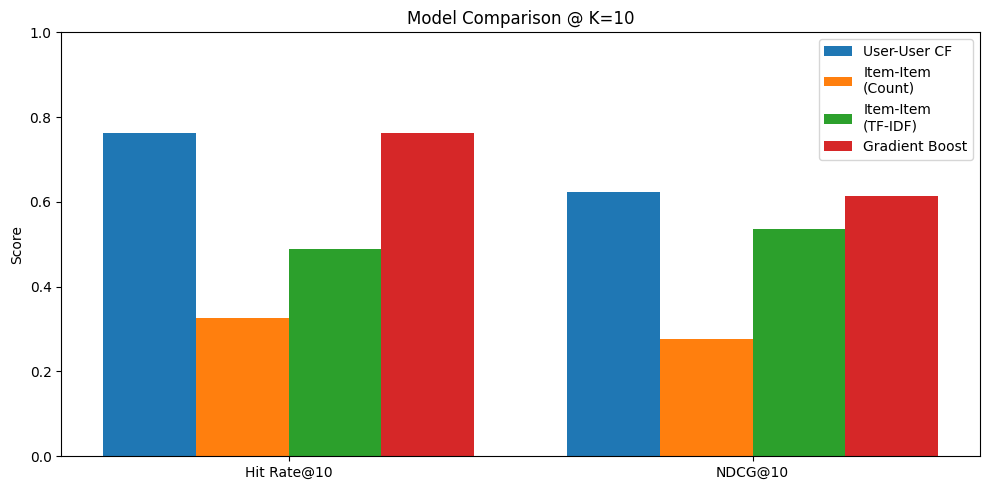

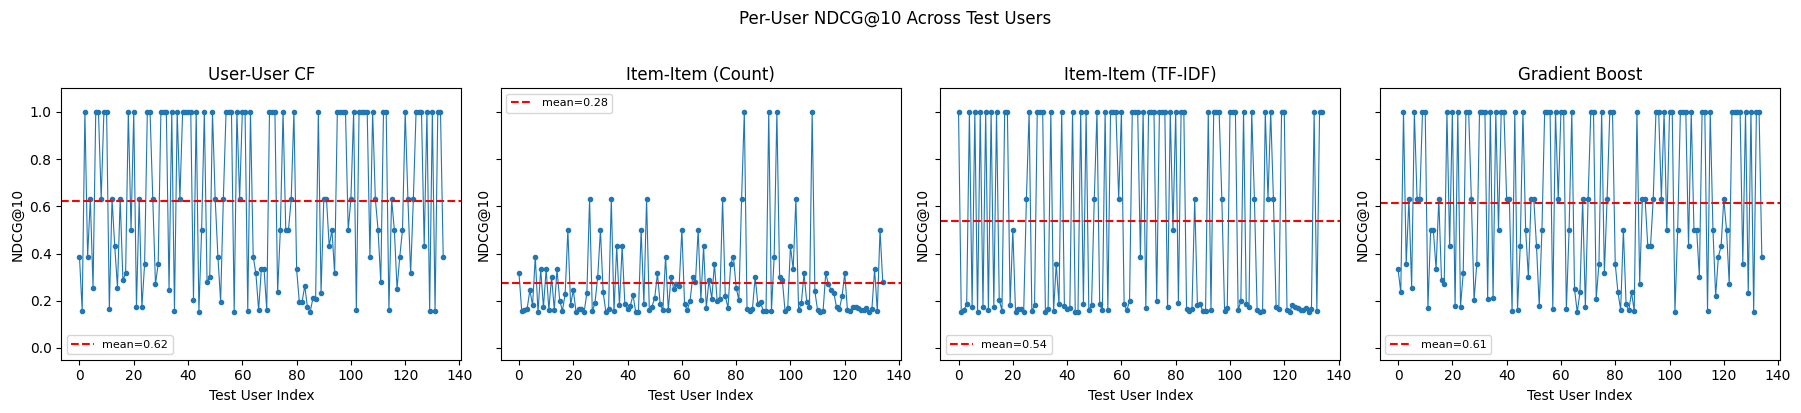

In [15]:
print(f'Evaluating on {len(test_users)} held-out test users...\n')

results_uu   = evaluate_model(score_user_user,       test_users)
results_ii   = evaluate_model(score_item_item,       test_users)
results_tfidf= evaluate_model(score_item_item_tfidf, test_users)
results_gb   = evaluate_model(score_gradient_boost,  test_users)

summary = pd.DataFrame({
    'Model':       ['User-User CF', 'Item-Item (Count)', 'Item-Item (TF-IDF)', 'Gradient Boost'],
    'Hit Rate@10': [results_uu['hit_rate'], results_ii['hit_rate'], results_tfidf['hit_rate'], results_gb['hit_rate']],
    'NDCG@10':     [results_uu['ndcg'],     results_ii['ndcg'],     results_tfidf['ndcg'],     results_gb['ndcg']],
    'Users Eval':  [results_uu['n_users'],  results_ii['n_users'],  results_tfidf['n_users'],  results_gb['n_users']],
})

print(summary.to_string(index=False))

# --- Bar chart ---
models_plot = ['User-User CF', 'Item-Item\n(Count)', 'Item-Item\n(TF-IDF)', 'Gradient Boost']
all_results = [results_uu, results_ii, results_tfidf, results_gb]
metrics     = ['Hit Rate@10', 'NDCG@10']
x     = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 5))
for i, (model, res) in enumerate(zip(models_plot, all_results)):
    vals = [res['hit_rate'], res['ndcg']]
    ax.bar(x + i * width, vals, width, label=model)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison @ K=10')
ax.legend()
plt.tight_layout()
plt.show()

# --- Per-user NDCG distributions ---
n = min(len(r['ndcg_list']) for r in all_results)

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax, label, res in zip(axes, models_plot, all_results):
    ax.plot(range(n), res['ndcg_list'][:n], marker='o', markersize=3, linewidth=0.8)
    ax.axhline(res['ndcg'], color='red', linestyle='--', label=f"mean={res['ndcg']:.2f}")
    ax.set_title(label.replace('\n', ' '))
    ax.set_xlabel('Test User Index')
    ax.set_ylabel('NDCG@10')
    ax.set_ylim(-0.05, 1.1)
    ax.legend(fontsize=8)

plt.suptitle('Per-User NDCG@10 Across Test Users', y=1.02)
plt.tight_layout()
plt.show()